## Step 1: Import libraries

In [1]:
import pandas as pd

## Step 2: Load transformed dataset

In [2]:
# Load data from previous step
df = pd.read_csv("../data/processed/train_transformed.csv")

df.head()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,1.791759,2.197225,1.791759,2.197225,1.945910,1.609438,1.609438,1.386294,1.386294,1.609438,...,1.791759,1.386294,1.386294,1.791759,1.609438,2.079442,1.791759,2.079442,1.386294,0.445
1,1.945910,2.079442,1.609438,1.609438,2.197225,2.197225,1.386294,1.791759,1.609438,1.945910,...,2.079442,1.098612,0.000000,1.386294,1.791759,1.386294,1.386294,1.609438,1.386294,0.450
2,1.945910,1.791759,1.945910,2.079442,1.386294,2.079442,0.693147,1.791759,1.609438,1.791759,...,2.079442,1.386294,2.079442,1.791759,1.945910,2.197225,1.098612,1.386294,1.386294,0.530
3,1.386294,1.609438,1.945910,1.791759,1.609438,2.197225,1.609438,2.079442,1.945910,2.197225,...,1.098612,1.609438,2.079442,1.609438,1.609438,1.945910,1.791759,2.079442,1.791759,0.535
4,1.791759,1.386294,1.098612,1.945910,1.609438,1.609438,1.386294,1.386294,1.386294,1.386294,...,1.098612,1.098612,1.945910,1.945910,1.609438,0.693147,1.098612,1.386294,1.791759,0.415


## Step 3: Drop irrelevant features

In [3]:
# Drop features not relevant for Nepal context
df = df.drop(["CoastalVulnerability", "PoliticalFactors"], axis=1)

## Step 4: Create new features (core logic)

In [4]:
# Rain + climate effect
df["RainFactor"] = df["MonsoonIntensity"] * df["ClimateChange"]

# Land pressure (human activities)
df["LandRisk"] = df["Deforestation"] + df["Urbanization"] + df["Encroachments"]

# Water system stress
df["WaterStress"] = df["RiverManagement"] + df["DrainageSystems"] + df["DamsQuality"]

# Blockage factor
df["Blockage"] = df["Siltation"] + df["Landslides"]

## Step 5: Check dataset

In [5]:
# Check updated columns
df.columns

Index(['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement',
       'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality',
       'Siltation', 'AgriculturalPractices', 'Encroachments',
       'IneffectiveDisasterPreparedness', 'DrainageSystems', 'Landslides',
       'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore',
       'WetlandLoss', 'InadequatePlanning', 'FloodProbability', 'RainFactor',
       'LandRisk', 'WaterStress', 'Blockage'],
      dtype='str')

## Step 7: Correlation check (after engineering)

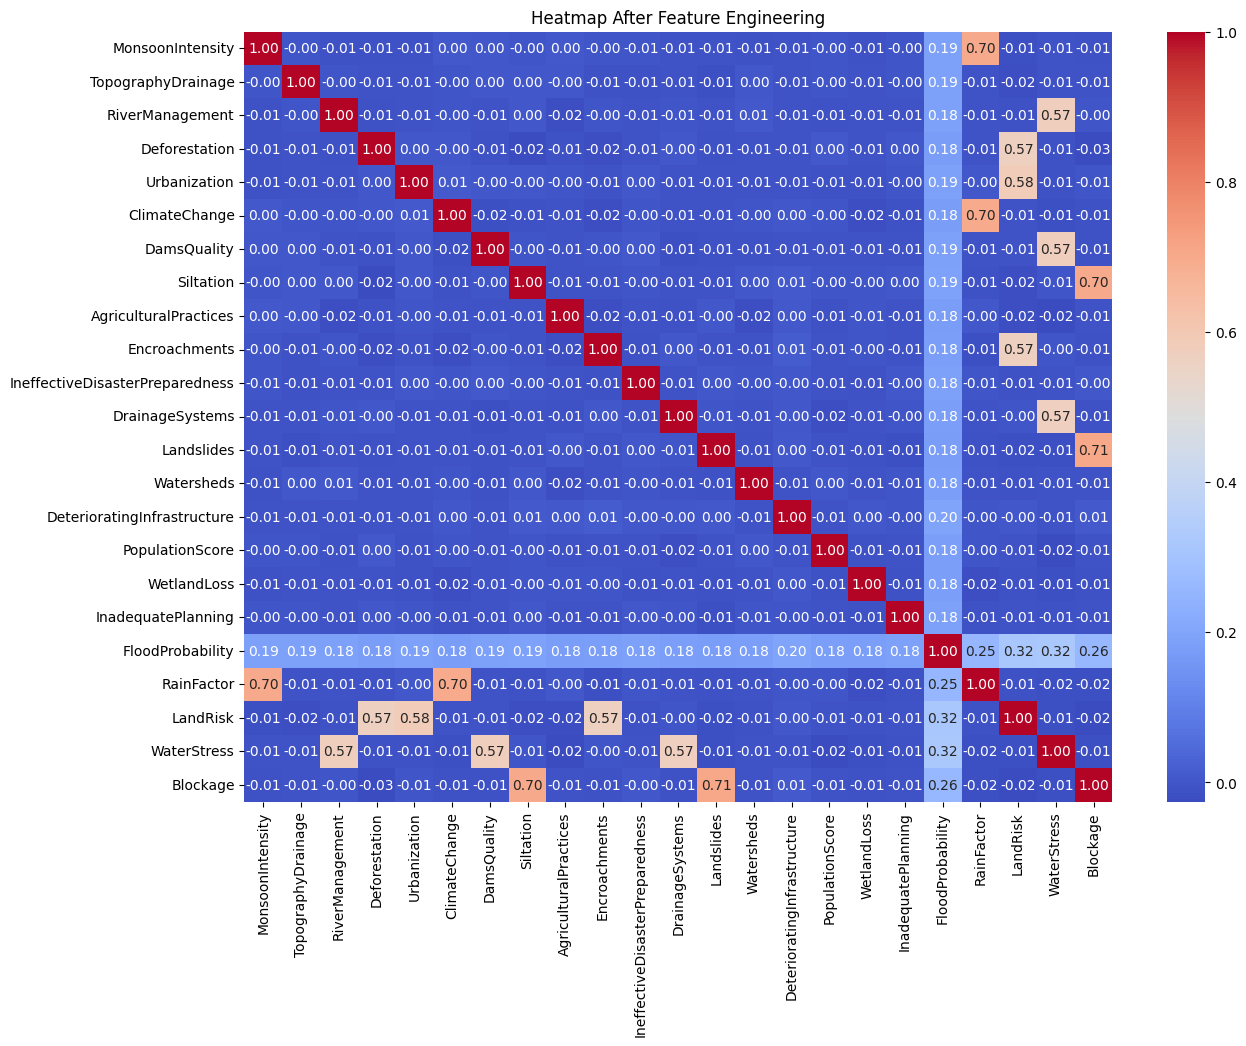

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Heatmap After Feature Engineering")
plt.show()

## Step 8: Save final dataset

In [7]:
import os

# Ensure folder exists
os.makedirs("../data/processed", exist_ok=True)

# Save final dataset
df.to_csv("../data/processed/train_final.csv", index=False)

## Step 8: Before vs After Feature Engineering Comparison

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# Load before and after datasets
before_df = pd.read_csv("../data/processed/train_transformed.csv")
after_df = pd.read_csv("../data/processed/train_final.csv")

# Drop features not used in final Nepal-context dataset
before_df = before_df.drop(["CoastalVulnerability", "PoliticalFactors"], axis=1)

# Prepare before dataset
X_before = before_df.drop("FloodProbability", axis=1)
y_before = before_df["FloodProbability"]

# Prepare after dataset
X_after = after_df.drop("FloodProbability", axis=1)
y_after = after_df["FloodProbability"]

# Convert target into binary class
y_before = (y_before >= y_before.median()).astype(int)
y_after = (y_after >= y_after.median()).astype(int)

# Same train-test split for fair comparison
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_before, y_before, test_size=0.2, random_state=42
)

Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    X_after, y_after, test_size=0.2, random_state=42
)

# Train same model before feature engineering
model_before = LogisticRegression(max_iter=1000)
model_before.fit(Xb_train, yb_train)
pred_before = model_before.predict(Xb_test)

# Train same model after feature engineering
model_after = LogisticRegression(max_iter=1000)
model_after.fit(Xa_train, ya_train)
pred_after = model_after.predict(Xa_test)

# Compare results
comparison = pd.DataFrame({
    "Dataset": ["Before Feature Engineering", "After Feature Engineering"],
    "Accuracy": [
        accuracy_score(yb_test, pred_before),
        accuracy_score(ya_test, pred_after)
    ],
    "F1 Score": [
        f1_score(yb_test, pred_before),
        f1_score(ya_test, pred_after)
    ]
})

comparison

,Dataset,Accuracy,F1 Score
0,Before Feature Engineering,0.781875,0.785600
1,After Feature Engineering,0.782250,0.785995


In [9]:
print(X_before.shape, X_after.shape)

(40000, 18) (40000, 22)
